In [2]:
import numpy as np
path = "/root/work/dhn/results/sinpend_kernel2_stride1/gen_sequence/denoise1_update1/result_dict.npy"
result=np.load(path, allow_pickle=True).item()

In [14]:
p_scale=result["p_scale"]
t=result["t"]
q_gt=result["q_gt"]
q_pred=result["q_pred"]
t.shape, q_gt.shape, q_pred.shape,p_scale.shape, result.keys()

((1000, 128),
 (1000, 128, 1),
 (1000, 128, 1),
 (1000,),
 dict_keys(['t', 'q_gt', 'p_gt', 'q_pred', 'p_pred', 'p_scale']))

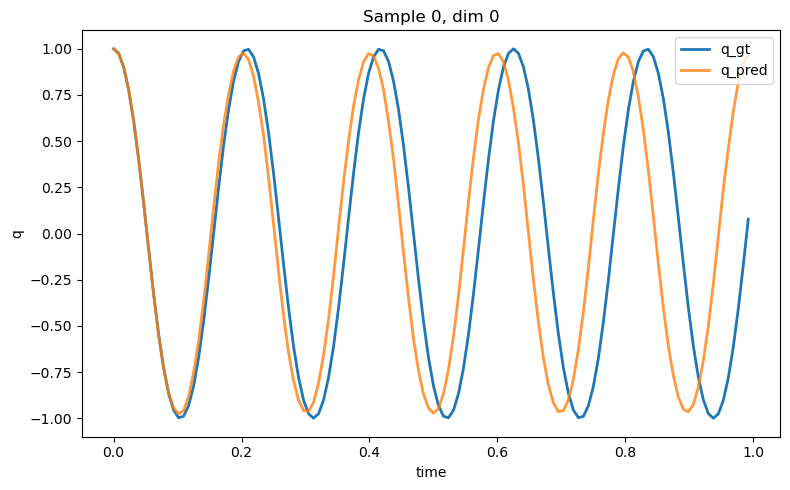

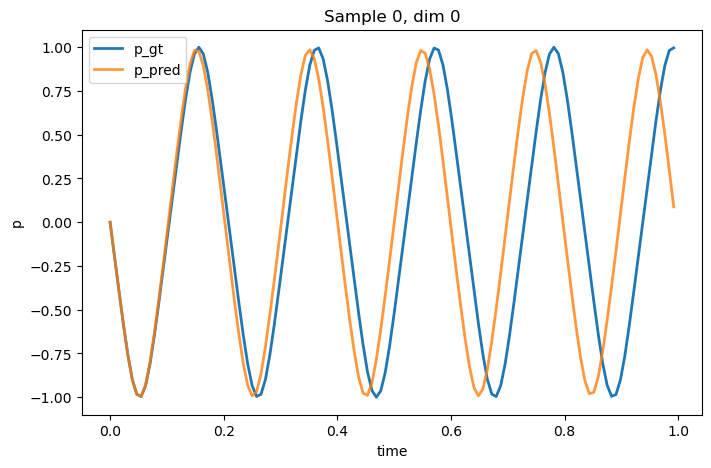

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Change these to your actual gen folder
gen_dir = "/root/work/dhn/results/sinpend_kernel2_stride1/gen_sequence"
# If there are multiple gen configs inside, pick one
# e.g., "ns20_stepsize1" — list directories to see what's there
subdirs = [d for d in os.listdir(gen_dir) if os.path.isdir(os.path.join(gen_dir, d))]
assert subdirs, f"No subdirectories found in {gen_dir}"
cfg_dir = os.path.join(gen_dir, subdirs[0])

result = np.load(os.path.join(cfg_dir, "result_dict.npy"), allow_pickle=True).item()

t = result["t"]          # shape: [N, T, 1]
q_gt = result["q_gt"]    # shape: [N, T, D]
q_pred = result["q_pred"]# shape: [N, T, D]

p_gt=result["p_gt"]
p_pred=result["p_pred"]

i = 0      # sample index to visualize
d = 0      # dimension index (0 for single pendulum)

tt = t[i]
plt.figure(figsize=(8,5))
plt.plot(tt, q_gt[i,:,d], label="q_gt", lw=2)
plt.plot(tt, q_pred[i,:,d], label="q_pred", lw=2, alpha=0.8)
plt.xlabel("time")
plt.ylabel("q")
plt.title(f"Sample {i}, dim {d}")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(tt, p_gt[i,:,d], label="p_gt", lw=2)
plt.plot(tt, p_pred[i,:,d], label="p_pred", lw=2, alpha=0.8)
plt.xlabel("time")
plt.ylabel("p")
plt.title(f"Sample {i}, dim {d}")
plt.legend()